# FMA Baseline — Log-Mel → 2D CNN (Version 2: TFRecord cache + FFmpeg + CUDA→XPU→CPU fallback)

Goal-1 controlled counterpart to `baseline_mfcc_cnn_v6.ipynb`.

**Intent:** keep the same task and training recipe while swapping only the **input representation**:
- MFCC baseline uses **13 MFCC coefficients**
- This notebook uses **128-band log-mel spectrograms**
- Same STFT params: `n_fft=512`, `hop_length=256`
- Same training recipe: **SGD lr=1e-3**, 20 epochs, batch size 16

**What changed in v2:** the preprocessing cache is now **TFRecord shards** (TensorFlow-native) instead of per-track `.npy` files.

References:
- `MelCNN-MGR/notebooks/baseline_mfcc_cnn_v6.ipynb`
- `docs/Final-Project-Proposal.md`


## Changelog (v1 → v2)

**Goal:** keep the Log-Mel baseline architecture + training behavior the same, but **remove `.npy` feature caches** and feed the model from **TFRecord shards** (TensorFlow-native input pipeline).

### What changed
- **Cache format:** per-track `cache/logmel/.../<track_id>.npy` → **per-split TFRecord shards** under `cache/tfrecord/logmel/<subset>/`.
- **Preprocessing output:** writes
  - `training-*.tfrecord`, `validation-*.tfrecord`, `test-*.tfrecord`
  - an index parquet per split for traceability (track_id, filepath, genre, status, shard pointer)
  - **train-only mean/std** saved to `logmel_train_stats_<subset>.npz` (per mel band).
- **Training input pipeline:** removed `tf.numpy_function(np.load)` and replaced with **`tf.data.TFRecordDataset`** + parsing/decoding + normalization.
- **Data integrity:** “usable rows” are now determined by what was actually written into TFRecords (skipped/corrupt tracks are tracked in the index parquet).  

### Why this matters
- `.npy` + `numpy_function` creates a Python bottleneck and lots of tiny-file I/O; TFRecords stream efficiently and keep GPU/XPU better fed.
- Makes it harder to accidentally evaluate on a “shrunk” subset due to missing cache files: the TFRecord manifest is the source of truth.



## 1. Imports


In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import os

warnings.filterwarnings("ignore", category=UserWarning)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print(f"Python     : {sys.version.split()[0]}")
print(f"TensorFlow : {tf.__version__}")


2026-03-06 11:38:15.120733: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-06 11:38:15.194326: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-06 11:38:15.194415: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-06 11:38:15.203163: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-06 11:38:15.231933: I tensorflow/core/platform/cpu_feature_guar

Python     : 3.11.14
TensorFlow : 2.15.1


## Device runtime selection (CUDA -> Intel XPU -> CPU)

This notebook prefers acceleration in this order:
1. CUDA GPU (`/GPU:0`)
2. Intel XPU (`/XPU:0`) via ITEX
3. CPU (`/CPU:0`)


## 2. Configuration & Hyperparameters

Set `SUBSET` to `"tiny"`, `"small"`, or `"medium"`.
Set `CLEAR_CACHE = True` to force re-extraction.


In [2]:
# -- Paths ---------------------------------------------------------------------
NOTEBOOK_DIR    = Path().resolve()
MELCNN_DIR      = NOTEBOOK_DIR.parent
WORKSPACE       = MELCNN_DIR.parent

PROCESSED_DIR   = MELCNN_DIR / "data" / "processed"
CACHE_DIR       = MELCNN_DIR / "cache"

# -- Per-run model directory ---------------------------------------------------
MODELS_BASE_DIR = MELCNN_DIR / "models"
RUN_DIR         = None

# -- Subset --------------------------------------------------------------------
SUBSET        = "small"   # "tiny" | "small" | "medium" | "large"
CLEAR_CACHE   = False

# -- Audio backend -------------------------------------------------------------
import shutil as _shutil
FFMPEG_AVAILABLE = _shutil.which("ffmpeg") is not None
AUDIO_BACKEND = "ffmpeg" if FFMPEG_AVAILABLE else "librosa"
print(f"[Audio] backend = {AUDIO_BACKEND} (ffmpeg_available={FFMPEG_AVAILABLE})")

# -- Performance knobs ---------------------------------------------------------
NUM_WORKERS   = min(6, (os.cpu_count() or 8))

# -- Audio sanity checks -------------------------------------------------------
MIN_SECONDS   = 1.0
SKIP_SILENT   = False
SILENCE_PEAK  = 1e-4
SILENCE_STD   = 1e-5

# -- Cache layout (TFRecord, per-split shards) ---------------------------------
# v2: we write TFRecord shards directly (no per-track .npy files).
TFRECORD_SHARD_SIZE = 1024
LOGMEL_TFRECORD_DIR = CACHE_DIR / "tfrecord" / "logmel" / SUBSET

# -- Training hyperparameters --------------------------------------------------
EPOCHS        = 20
BATCH_SIZE    = 16

# -- Log-mel extraction params -------------------------------------------------
SAMPLE_RATE   = 22050
N_MELS        = 128
N_FFT         = 512
HOP_LENGTH    = 256
N_FRAMES      = 2582
LOGMEL_SHAPE  = (N_MELS, N_FRAMES)

# -- Reproducibility seed ------------------------------------------------------
SEED = 42

import random
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"[Seed] SEED={SEED} applied to random / numpy / tensorflow")

# -- Global timer --------------------------------------------------------------
import time as _time_module
_T0             = _time_module.perf_counter()
_section_times  = {}

[Audio] backend = ffmpeg (ffmpeg_available=True)
[Seed] SEED=42 applied to random / numpy / tensorflow


In [3]:
_t0 = _time_module.perf_counter()

import platform
import traceback

def _best_effort_set_memory_growth(tf, device_type: str):
    devs = tf.config.list_physical_devices(device_type)
    for d in devs:
        try:
            tf.config.experimental.set_memory_growth(d, True)
        except Exception:
            pass
    return devs

def _smoke_test_matmul(tf, device: str, n: int = 1024) -> tuple[bool, str]:
    try:
        with tf.device(device):
            a = tf.random.normal([n, n])
            b = tf.random.normal([n, n])
            c = tf.matmul(a, b)
            _ = c[0, 0].numpy()
        return True, "ok"
    except Exception as e:
        return False, repr(e)

def configure_runtime_device(tf):
    print(f"Platform   : {platform.platform()}")
    print(f"TensorFlow : {tf.__version__}")

    try:
        gpus = _best_effort_set_memory_growth(tf, "GPU")
    except Exception:
        gpus = []
    if gpus:
        ok, info = _smoke_test_matmul(tf, "/GPU:0", n=1024)
        if ok:
            return "/GPU:0", "cuda", [d.name for d in gpus], info
        print("CUDA present but failed smoke test ->", info)

    try:
        import intel_extension_for_tensorflow as itex  # noqa: F401
        xpus = _best_effort_set_memory_growth(tf, "XPU")
    except Exception as e:
        xpus = []
        print("ITEX/XPU not available:", repr(e))

    if xpus:
        ok, info = _smoke_test_matmul(tf, "/XPU:0", n=1024)
        if ok:
            return "/XPU:0", "xpu", [d.name for d in xpus], info
        print("XPU present but failed smoke test ->", info)

    return "/CPU:0", "cpu", [], "ok"

RUNTIME_DEVICE, BACKEND, ACCEL_NAMES, SMOKE_INFO = configure_runtime_device(tf)

print(f"Backend    : {BACKEND.upper()} ({RUNTIME_DEVICE})")
if ACCEL_NAMES:
    print(f"Devices    : {ACCEL_NAMES}")
else:
    print("Devices    : none detected -> CPU fallback")
print(f"Smoke test : {SMOKE_INFO}")

_section_times["2. Device setup"] = _time_module.perf_counter() - _t0
print()
print(f"Device setup : {_section_times['2. Device setup']:.2f}s")


Platform   : Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
TensorFlow : 2.15.1


2026-03-06 11:38:47.146224: I tensorflow/core/common_runtime/next_pluggable_device/next_pluggable_device_factory.cc:118] Created 1 TensorFlow NextPluggableDevices. Physical device type: XPU


Backend    : XPU (/XPU:0)
Devices    : ['/physical_device:XPU:0']
Smoke test : ok

Device setup : 4.01s


## 3. Load Manifest Splits


In [4]:
_t0 = _time_module.perf_counter()

def load_manifest_splits(processed_dir: Path, subset: str):
    def _load(name: str) -> pd.DataFrame:
        path = processed_dir / f"{name}_{subset}.parquet"
        if not path.exists():
            msg_lines = [
                f"Manifest parquet not found: {path}",
                "Run build_manifest.py first:",
                "  python MelCNN-MGR/preprocessing/build_manifest.py",
            ]
            raise FileNotFoundError(chr(10).join(msg_lines))
        return pd.read_parquet(path)

    train_df = _load("train")
    val_df   = _load("val")
    test_df  = _load("test")
    return train_df, val_df, test_df

print("Loading manifest parquets ...")
train_df, val_df, test_df = load_manifest_splits(PROCESSED_DIR, SUBSET)

print(f"  train : {len(train_df):>5,} rows")
print(f"  val   : {len(val_df):>5,} rows")
print(f"  test  : {len(test_df):>5,} rows")

all_genres    = sorted(pd.concat([train_df, val_df, test_df])["genre_top"].unique().tolist())
N_CLASSES     = len(all_genres)
GENRE_CLASSES = all_genres
print()
print(f"  Genres ({N_CLASSES}): {GENRE_CLASSES}")

label_enc = LabelEncoder().fit(GENRE_CLASSES)

_section_times["3. Load manifest"] = _time_module.perf_counter() - _t0
print()
print(f"Load manifest : {_section_times['3. Load manifest']:.2f}s")


Loading manifest parquets ...
  train : 6,400 rows
  val   :   800 rows
  test  :   800 rows

  Genres (8): ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']

Load manifest : 0.24s


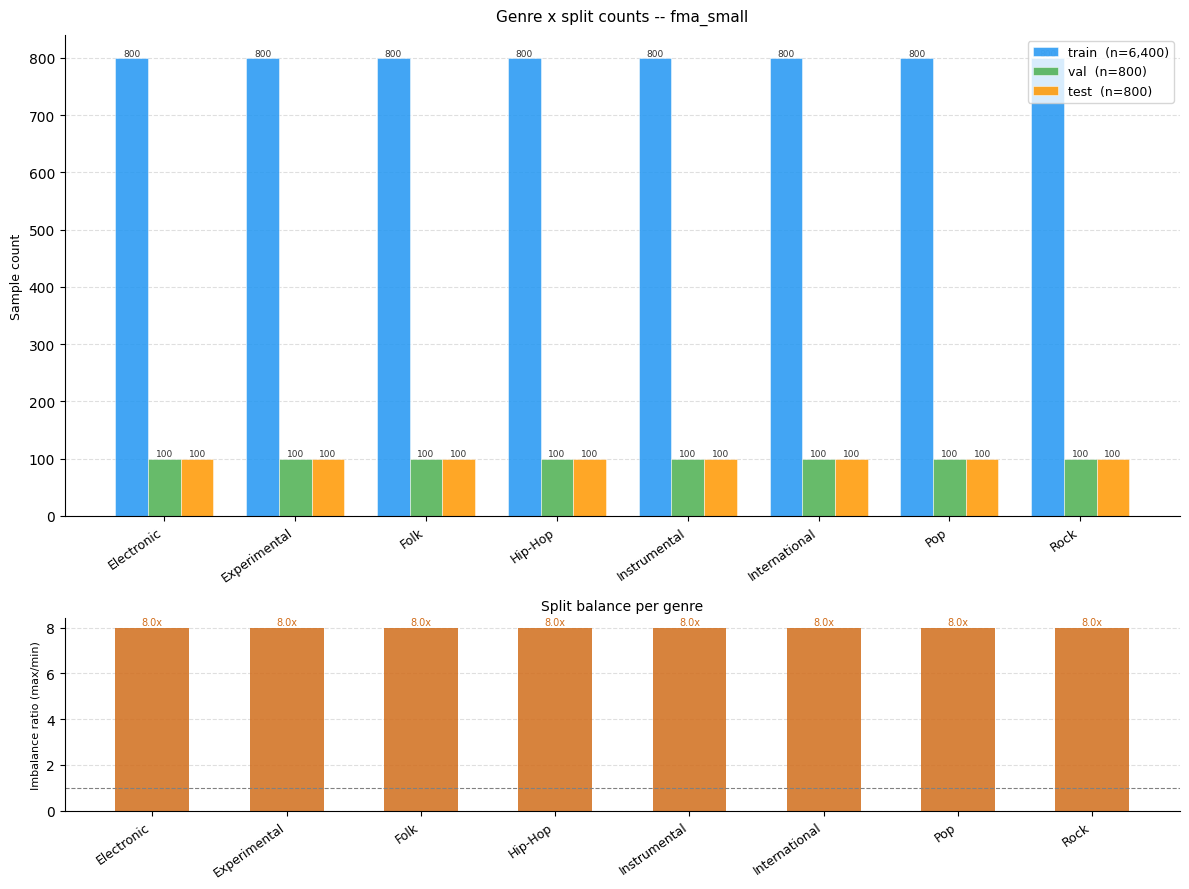

Most imbalanced genre across splits : Electronic  (ratio = 8.00x)
-> Significant imbalance detected -- consider class-weighted loss or reporting Macro-F1 as the primary metric.

Genre distribution plot : 1.11s


In [5]:
_t0 = _time_module.perf_counter()

splits      = ["train", "val", "test"]
dfs         = [train_df, val_df, test_df]
split_colors = ["#2196F3", "#4CAF50", "#FF9800"]

genres_sorted = sorted(all_genres)
n_genres      = len(genres_sorted)

counts_matrix = np.array(
    [[df["genre_top"].value_counts().get(g, 0) for df in dfs] for g in genres_sorted],
    dtype=int,
)

row_max   = counts_matrix.max(axis=1).astype(float)
row_min   = np.where(counts_matrix.min(axis=1) == 0, 1, counts_matrix.min(axis=1)).astype(float)
imbalance = row_max / row_min

fig, (ax_bar, ax_imb) = plt.subplots(
    2, 1,
    figsize=(max(12, n_genres * 0.9), 9),
    gridspec_kw={"height_ratios": [3, 1.2]},
)

x       = np.arange(n_genres)
n_grps  = len(splits)
width   = 0.25
offsets = np.linspace(-(n_grps - 1) / 2, (n_grps - 1) / 2, n_grps) * width

for j, (split, color, offset) in enumerate(zip(splits, split_colors, offsets)):
    counts = counts_matrix[:, j]
    bars   = ax_bar.bar(x + offset, counts, width=width,
                        label=f"{split}  (n={counts.sum():,})",
                        color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
    for bar, cnt in zip(bars, counts):
        if cnt > 0:
            ax_bar.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                str(cnt),
                ha="center", va="bottom", fontsize=6.5, color="#333333",
            )

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(genres_sorted, rotation=35, ha="right", fontsize=9)
ax_bar.set_ylabel("Sample count", fontsize=9)
ax_bar.set_title(f"Genre x split counts -- fma_{SUBSET}", fontsize=11, pad=10)
ax_bar.legend(fontsize=9, loc="upper right")
for spine in ["top", "right"]:
    ax_bar.spines[spine].set_visible(False)
ax_bar.yaxis.grid(True, linestyle="--", alpha=0.4)
ax_bar.set_axisbelow(True)

bar_colors = ["#d16d1b" if r > 1.5 else "#159dd3" for r in imbalance]
ax_imb.bar(x, imbalance, color=bar_colors, width=0.55, edgecolor="none", alpha=0.85)
ax_imb.axhline(1.0, color="grey", linewidth=0.8, linestyle="--")
ax_imb.set_xticks(x)
ax_imb.set_xticklabels(genres_sorted, rotation=35, ha="right", fontsize=9)
ax_imb.set_ylabel("Imbalance ratio (max/min)", fontsize=8)
ax_imb.set_title("Split balance per genre", fontsize=10, pad=6)
for i, (xi, r) in enumerate(zip(x, imbalance)):
    ax_imb.text(xi, r + 0.03, f"{r:.1f}x", ha="center", va="bottom",
                fontsize=7, color="#d16d1b" if r > 1.5 else "#159dd3")
for spine in ["top", "right"]:
    ax_imb.spines[spine].set_visible(False)
ax_imb.yaxis.grid(True, linestyle="--", alpha=0.4)
ax_imb.set_axisbelow(True)

plt.tight_layout()
plt.show()

worst_genre = genres_sorted[int(np.argmax(imbalance))]
worst_ratio = float(imbalance.max())
print(f"Most imbalanced genre across splits : {worst_genre}  (ratio = {worst_ratio:.2f}x)")
if worst_ratio <= 1.05:
    print("-> All genres are near-perfectly balanced across splits.")
elif worst_ratio <= 2.0:
    print("-> Minor imbalance; using class-weighted loss is optional.")
else:
    print("-> Significant imbalance detected -- consider class-weighted loss or reporting Macro-F1 as the primary metric.")

_section_times["3b. Genre plot"] = _time_module.perf_counter() - _t0
print()
print(f"Genre distribution plot : {_section_times['3b. Genre plot']:.2f}s")


## 4. Log-Mel Feature Extraction

Each 30-second clip is loaded at `sr=22050 Hz`, and a 128-band log-mel spectrogram is
computed with `n_fft=512`, `hop_length=256`, yielding a `(128, 2582)` matrix.
Shorter clips are zero-padded; longer ones are truncated.
Results are written into **TFRecord shards** so subsequent runs can stream data efficiently (no per-track `.npy`).

### Corrupt or unreadable tracks

Some tracks in each split may be silently dropped:

* source MP3 cannot be decoded (corrupt file or truncated download)
* decoded audio is too short, empty, or has non-finite samples
* feature extraction fails for this track (e.g., spectrogram computation error)

If TFRecord cache artifacts already exist (index + manifest + stats), they are reused; set `CLEAR_CACHE=True` to rebuild from scratch.
The final "Usable rows" printout at the end of this section shows how many tracks
from each split actually reach the model — compare against the manifest totals to
detect any data-quality losses before interpreting results.


In [6]:
import librosa
import subprocess
import concurrent.futures as _fut
import json as _json
import math as _math

# ─────────────────────────────────────────────────────────────────────────────
# Log-mel extraction → TFRecord (Version 2)
#   - decode: ffmpeg (preferred) or librosa.load (fallback)
#   - compute: librosa.feature.melspectrogram → log1p
#   - write: per-split TFRecord shards (streamable by tf.data)
#   - record: per-split index parquet + manifest json for traceability
#   - stats: train-only mean/std (per mel band) saved once
# ─────────────────────────────────────────────────────────────────────────────

def _track_id_from_path(filepath: Path) -> int:
    # FMA files are usually <track_id>.mp3, so use filename stem as id.
    try:
        return int(Path(filepath).stem)
    except Exception:
        return abs(hash(str(filepath))) % (10**12)

def _load_audio_ffmpeg(filepath: Path, sr: int, mono: bool = True, duration: float = 30.0) -> np.ndarray:
    cmd = ["ffmpeg", "-v", "error", "-i", str(filepath), "-vn", "-sn", "-dn"]
    if duration is not None:
        cmd += ["-t", str(duration)]
    cmd += ["-ar", str(sr)]
    if mono:
        cmd += ["-ac", "1"]
    cmd += ["-f", "f32le", "pipe:1"]

    proc = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, check=False)
    if proc.returncode != 0:
        err = proc.stderr.decode("utf-8", errors="ignore").strip()
        raise RuntimeError(f"ffmpeg decode failed: {err}")
    y = np.frombuffer(proc.stdout, dtype=np.float32)
    if y.size == 0:
        raise RuntimeError("ffmpeg produced empty output")
    return y

def _load_audio_simple(filepath: Path, sr: int, mono: bool = True, duration: float = 30.0) -> np.ndarray:
    if AUDIO_BACKEND == "ffmpeg":
        return _load_audio_ffmpeg(filepath, sr=sr, mono=mono, duration=duration)
    y, _sr = librosa.load(str(filepath), sr=sr, mono=mono, duration=duration)
    return y.astype(np.float32, copy=False)

def _sanity_check_audio(y: np.ndarray, sr: int) -> tuple[bool, str]:
    if y is None or len(y) == 0:
        return False, "empty_audio"
    if not np.isfinite(y).all():
        return False, "non_finite_samples"
    if len(y) < int(MIN_SECONDS * sr):
        return False, f"too_short(<{MIN_SECONDS}s)"
    if SKIP_SILENT:
        peak = float(np.max(np.abs(y)))
        st   = float(np.std(y))
        if peak < SILENCE_PEAK or st < SILENCE_STD:
            return False, "near_silent"
    return True, ""

def _logmel_fixed_shape(y: np.ndarray) -> np.ndarray:
    S = librosa.feature.melspectrogram(
        y=y, sr=SAMPLE_RATE, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    logmel = np.log1p(S)
    out = np.zeros(LOGMEL_SHAPE, dtype=np.float32)
    n = min(logmel.shape[1], N_FRAMES)
    out[:, :n] = logmel[:, :n].astype(np.float32, copy=False)
    return out

# ── TFRecord helpers ─────────────────────────────────────────────────────────
def _bytes_feature(b: bytes) -> tf.train.Feature:
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[b]))

def _int64_feature(v) -> tf.train.Feature:
    if isinstance(v, (list, tuple, np.ndarray)):
        return tf.train.Feature(int64_list=tf.train.Int64List(value=[int(x) for x in v]))
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[int(v)]))

def _serialize_example(x_bytes: bytes, y_int: int, track_id: int) -> bytes:
    ex = tf.train.Example(features=tf.train.Features(feature={
        "x":        _bytes_feature(x_bytes),      # float32 bytes, shape LOGMEL_SHAPE
        "y":        _int64_feature(y_int),        # label int
        "track_id": _int64_feature(track_id),     # for traceability/debugging
        "shape":    _int64_feature(list(LOGMEL_SHAPE)),
    }))
    return ex.SerializeToString()

# ── Per-track worker (thread-safe) ────────────────────────────────────────────
def _process_one_track_tfrecord(task: tuple) -> dict:
    filepath_str, split_name, genre_top, label_int, track_id = task
    filepath = Path(filepath_str)

    try:
        y = _load_audio_simple(filepath, sr=SAMPLE_RATE, mono=True, duration=30.0)
    except Exception as exc:
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "label_int": int(label_int),
            "status": "skipped",
            "reason": f"decode_fail:{type(exc).__name__}",
        }

    ok, reason = _sanity_check_audio(y, SAMPLE_RATE)
    if not ok:
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "label_int": int(label_int),
            "status": "skipped",
            "reason": reason,
        }

    try:
        logmel = _logmel_fixed_shape(y)  # (N_MELS, N_FRAMES), float32
        x_bytes = logmel.tobytes(order="C")
        sum_c   = logmel.sum(axis=1, dtype=np.float64)                 # (N_MELS,)
        sumsq_c = (logmel * logmel).sum(axis=1, dtype=np.float64)      # (N_MELS,)
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "label_int": int(label_int),
            "status": "ok",
            "reason": "",
            "x_bytes": x_bytes,
            "sum_c": sum_c,
            "sumsq_c": sumsq_c,
            "n_frames": int(logmel.shape[1]),
        }
    except Exception as exc:
        return {
            "track_id": track_id,
            "filepath": filepath_str,
            "split": split_name,
            "genre_top": genre_top,
            "label_int": int(label_int),
            "status": "skipped",
            "reason": f"logmel_fail:{type(exc).__name__}",
        }

def build_logmel_tfrecord_split(
    split_df: pd.DataFrame,
    split_name: str,
    out_dir: Path,
    num_workers: int,
    shard_size: int,
    compute_train_stats: bool = False,
) -> tuple[pd.DataFrame, dict]:
    """
    Build (or load) TFRecord shards for one split and return:
      - index_df (one row per input track, including skipped rows)
      - manifest dict (paths + counts + stats pointer if any)
    """
    out_dir.mkdir(parents=True, exist_ok=True)

    index_path    = out_dir / f"logmel_tfrecord_index_{split_name}_{SUBSET}.parquet"
    manifest_path = out_dir / f"logmel_tfrecord_manifest_{split_name}_{SUBSET}.json"
    stats_path    = out_dir / f"logmel_train_stats_{SUBSET}.npz" if compute_train_stats else None

    # Cached build
    if index_path.exists() and manifest_path.exists() and (not compute_train_stats or (stats_path and stats_path.exists())):
        print(f"  [{split_name}] Loading TFRecord index + manifest from cache …")
        index_df = pd.read_parquet(index_path)
        manifest = _json.loads(manifest_path.read_text())
        return index_df, manifest

    print(f"  [{split_name}] Building TFRecords with {num_workers} workers …")
    tasks = []
    for row in split_df.itertuples(index=False):
        fp = getattr(row, "filepath") if hasattr(row, "filepath") else row[split_df.columns.get_loc("filepath")]
        gt = getattr(row, "genre_top") if hasattr(row, "genre_top") else row[split_df.columns.get_loc("genre_top")]
        tid = _track_id_from_path(fp)
        y_int = int(label_enc.transform([str(gt)])[0])
        tasks.append((str(fp), split_name, str(gt), y_int, int(tid)))

    # Writer state (sharded)
    shard_id = 0
    in_shard = 0
    writer = None
    tfrecord_files = []

    def _open_new_writer():
        nonlocal shard_id, in_shard, writer
        if writer is not None:
            writer.close()
        tf_path = out_dir / f"{split_name}-{shard_id:05d}.tfrecord"
        tfrecord_files.append(str(tf_path))
        writer = tf.io.TFRecordWriter(str(tf_path))
        in_shard = 0
        shard_id += 1

    # Train stats accumulators (per mel band)
    sum_c_total   = np.zeros((N_MELS,), dtype=np.float64)
    sumsq_c_total = np.zeros((N_MELS,), dtype=np.float64)
    count_frames  = 0

    results = []
    skipped = 0
    written = 0
    t0 = time.time()

    _open_new_writer()

    # NOTE: For log-mel, each example is ~1.3MB; using threads avoids pickling huge arrays/bytes.
    with _fut.ThreadPoolExecutor(max_workers=num_workers) as ex:
        for i, res in enumerate(ex.map(_process_one_track_tfrecord, tasks), start=1):
            row_out = {
                "track_id": res.get("track_id"),
                "filepath": res.get("filepath"),
                "split": res.get("split"),
                "genre_top": res.get("genre_top"),
                "label_int": res.get("label_int"),
                "status": res.get("status"),
                "reason": res.get("reason", ""),
                "tfrecord": "",
                "example_in_shard": -1,
            }

            if res.get("status") == "ok":
                if in_shard >= shard_size:
                    _open_new_writer()

                writer.write(_serialize_example(res["x_bytes"], int(res["label_int"]), int(res["track_id"])))
                row_out["tfrecord"] = tfrecord_files[-1]
                row_out["example_in_shard"] = int(in_shard)

                in_shard += 1
                written += 1

                if compute_train_stats:
                    sum_c_total   += res["sum_c"]
                    sumsq_c_total += res["sumsq_c"]
                    count_frames  += int(res.get("n_frames", N_FRAMES))
            else:
                skipped += 1

            results.append(row_out)

            if i % 100 == 0 or i == len(tasks):
                elapsed = time.time() - t0
                print(f"    {i}/{len(tasks)}  written={written}  skipped={skipped}  — {elapsed:.0f}s elapsed")

    if writer is not None:
        writer.close()

    index_df = pd.DataFrame(results)
    index_df.to_parquet(index_path, index=False)

    manifest = {
        "version": 2,
        "representation": "logmel",
        "subset": SUBSET,
        "split_name": split_name,
        "expected_shape": list(LOGMEL_SHAPE),
        "n_total": int(len(tasks)),
        "n_written": int(written),
        "n_skipped": int(skipped),
        "shard_size": int(shard_size),
        "tfrecord_files": tfrecord_files,
        "index_parquet": str(index_path),
    }

    if compute_train_stats:
        mean = sum_c_total / max(1, count_frames)
        var  = (sumsq_c_total / max(1, count_frames)) - mean**2
        std  = np.sqrt(np.maximum(var, 1e-12))

        mu  = mean.reshape((1, N_MELS, 1, 1)).astype(np.float32)
        sig = std.reshape((1, N_MELS, 1, 1)).astype(np.float32)

        np.savez(stats_path, mu=mu, std=sig, mean_1d=mean.astype(np.float32), std_1d=std.astype(np.float32), count_frames=int(count_frames))
        manifest["train_stats_npz"] = str(stats_path)

    manifest_path.write_text(_json.dumps(manifest, indent=2))
    print(f"    Saved index    → {index_path}")
    print(f"    Saved manifest → {manifest_path}")
    if compute_train_stats:
        print(f"    Saved stats    → {stats_path}")

    return index_df, manifest


In [7]:
_t0 = _time_module.perf_counter()

import shutil as _shutil

print("Building/loading log-mel TFRecord shards + index parquets …\n")
print(f"TFRecord dir : {LOGMEL_TFRECORD_DIR}")

# Optional reset (subset-scoped)
if CLEAR_CACHE and LOGMEL_TFRECORD_DIR.exists():
    print("[CLEAR_CACHE] Deleting existing TFRecord cache for this subset …")
    _shutil.rmtree(LOGMEL_TFRECORD_DIR, ignore_errors=True)

# Build per split (train also computes + saves train-only mean/std)
train_index, train_manifest = build_logmel_tfrecord_split(
    train_df, "training",
    out_dir=LOGMEL_TFRECORD_DIR,
    num_workers=NUM_WORKERS,
    shard_size=TFRECORD_SHARD_SIZE,
    compute_train_stats=True,
)
val_index, val_manifest = build_logmel_tfrecord_split(
    val_df, "validation",
    out_dir=LOGMEL_TFRECORD_DIR,
    num_workers=NUM_WORKERS,
    shard_size=TFRECORD_SHARD_SIZE,
    compute_train_stats=False,
)
test_index, test_manifest = build_logmel_tfrecord_split(
    test_df, "test",
    out_dir=LOGMEL_TFRECORD_DIR,
    num_workers=NUM_WORKERS,
    shard_size=TFRECORD_SHARD_SIZE,
    compute_train_stats=False,
)

def _usable(df: pd.DataFrame) -> pd.DataFrame:
    return df[df["status"].isin(["ok"])].reset_index(drop=True)

train_index_u = _usable(train_index)
val_index_u   = _usable(val_index)
test_index_u  = _usable(test_index)

print("\nUsable rows (written into TFRecords):")
print(f"  train : {len(train_index_u):>5,} / {len(train_df):>5,} (skipped {train_manifest['n_skipped']})")
print(f"  val   : {len(val_index_u):>5,} / {len(val_df):>5,} (skipped {val_manifest['n_skipped']})")
print(f"  test  : {len(test_index_u):>5,} / {len(test_df):>5,} (skipped {test_manifest['n_skipped']})")

_section_times["4. Log-mel TFRecord build"] = _time_module.perf_counter() - _t0
print(f"\nLog-mel TFRecord build : {_section_times['4. Log-mel TFRecord build']:.2f}s")


Building/loading log-mel TFRecord shards + index parquets …

TFRecord dir : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/cache/tfrecord/logmel/small
  [training] Loading TFRecord index + manifest from cache …
  [validation] Loading TFRecord index + manifest from cache …
  [test] Loading TFRecord index + manifest from cache …

Usable rows (written into TFRecords):
  train : 6,396 / 6,400 (skipped 4)
  val   :   800 /   800 (skipped 0)
  test  :   800 /   800 (skipped 0)

Log-mel TFRecord build : 0.18s


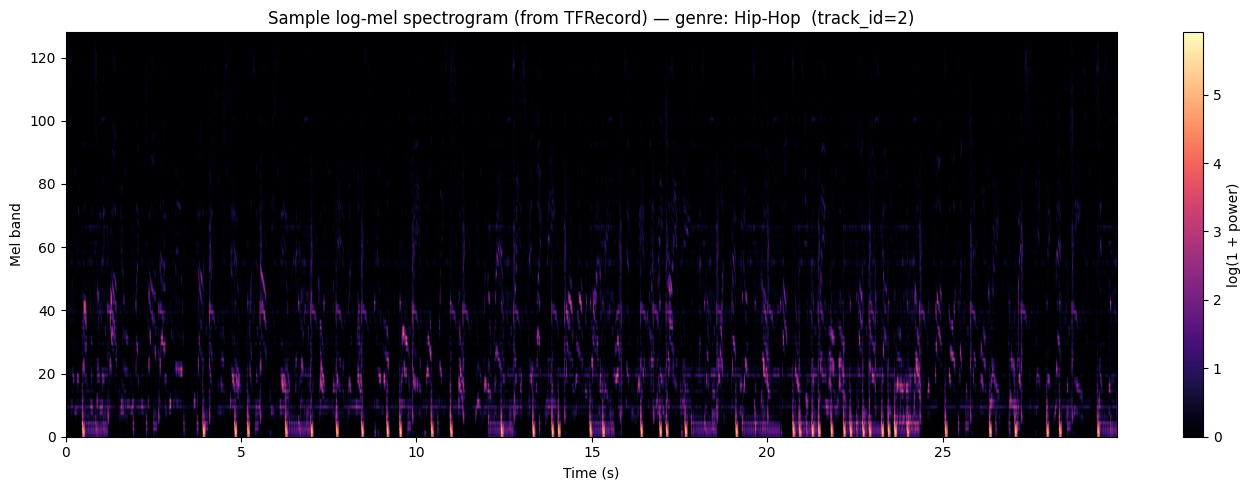

Log-mel sample plot : 0.75s


In [8]:
_t0 = _time_module.perf_counter()

# ── Visualise one example log-mel from the *TFRecord training set* ────────────
tf_path = train_manifest["tfrecord_files"][0]
raw_rec = next(iter(tf.data.TFRecordDataset([tf_path]).take(1))).numpy()

ex = tf.train.Example.FromString(raw_rec)
x_bytes  = ex.features.feature["x"].bytes_list.value[0]
track_id = int(ex.features.feature["track_id"].int64_list.value[0])
label_i  = int(ex.features.feature["y"].int64_list.value[0])

logmel = np.frombuffer(x_bytes, dtype=np.float32).reshape(LOGMEL_SHAPE)
genre  = GENRE_CLASSES[label_i]

fig, ax = plt.subplots(figsize=(14, 5))
img = ax.imshow(logmel, aspect="auto", origin="lower",
                extent=[0, N_FRAMES * HOP_LENGTH / SAMPLE_RATE, 0, N_MELS],
                cmap="magma")
ax.set_title(f"Sample log-mel spectrogram (from TFRecord) — genre: {genre}  (track_id={track_id})")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mel band")
plt.colorbar(img, ax=ax, label="log(1 + power)")
plt.tight_layout()
plt.show()

_section_times["4b. Log-mel plot"] = _time_module.perf_counter() - _t0
print(f"Log-mel sample plot : {_section_times['4b. Log-mel plot']:.2f}s")


## 5. Preprocessing


In [9]:
_t0 = _time_module.perf_counter()

# ── Load train-only normalization stats (computed during TFRecord build) ──────
stats_path = Path(train_manifest["train_stats_npz"])
stats = np.load(stats_path)

mu  = stats["mu"].astype(np.float32)   # (1, 128, 1, 1)
std = stats["std"].astype(np.float32)  # (1, 128, 1, 1)

print(f"Loaded train stats: {stats_path.name}")
print(f"  mu  shape={mu.shape}")
print(f"  std shape={std.shape}")

# ── tf.data input pipeline (TFRecordDataset) ─────────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE
mu_tf  = tf.constant(mu, dtype=tf.float32)
std_tf = tf.constant(std, dtype=tf.float32)

_FEATURE_SPEC = {
    "x": tf.io.FixedLenFeature([], tf.string),
    "y": tf.io.FixedLenFeature([], tf.int64),
    "track_id": tf.io.FixedLenFeature([], tf.int64),
    "shape": tf.io.FixedLenFeature([2], tf.int64),
}

def _parse_and_norm(example_proto):
    ex = tf.io.parse_single_example(example_proto, _FEATURE_SPEC)
    x = tf.io.decode_raw(ex["x"], tf.float32)
    x = tf.reshape(x, (*LOGMEL_SHAPE, 1))
    x = (x - mu_tf[0]) / std_tf[0]
    y = tf.cast(ex["y"], tf.int32)
    y_oh = tf.one_hot(y, N_CLASSES)
    return x, y_oh

def make_dataset(manifest: dict, batch_size: int, shuffle: bool) -> tf.data.Dataset:
    files = [str(p) for p in manifest["tfrecord_files"]]
    ds = tf.data.TFRecordDataset(files, num_parallel_reads=AUTOTUNE)

    ds = ds.map(_parse_and_norm, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=4096, seed=SEED, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_manifest, BATCH_SIZE, shuffle=True)
val_ds   = make_dataset(val_manifest,   BATCH_SIZE, shuffle=False)
test_ds  = make_dataset(test_manifest,  BATCH_SIZE, shuffle=False)

print("Datasets ready:")
print(f"  train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"  val   batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"  test  batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

_section_times["5. Preprocessing"] = _time_module.perf_counter() - _t0
print(f"\nPreprocessing : {_section_times['5. Preprocessing']:.2f}s")


Loaded train stats: logmel_train_stats_small.npz
  mu  shape=(1, 128, 1, 1)
  std shape=(1, 128, 1, 1)
Datasets ready:
  train batches: -2
  val   batches: -2
  test  batches: -2

Preprocessing : 0.51s


## 6. Build the CNN Model


In [10]:
_t0 = _time_module.perf_counter()

def build_model(n_classes: int) -> keras.Model:
    inputs = keras.Input(shape=(*LOGMEL_SHAPE, 1), name="logmel")

    x = layers.Conv2D(3,  (N_MELS, 10), strides=(1, 4), padding="valid", activation="relu", name="conv1")(inputs)
    x = layers.Conv2D(15, (1,  10), strides=(1, 4), padding="valid", activation="relu", name="conv2")(x)
    x = layers.Conv2D(65, (1,  10), strides=(1, 4), padding="valid", activation="relu", name="conv3")(x)
    x = layers.Flatten(name="flatten")(x)
    outputs = layers.Dense(n_classes, activation="softmax", name="fc_out")(x)

    return keras.Model(inputs, outputs, name="logmel_2dcnn_baseline")

with tf.device(RUNTIME_DEVICE):
    model = build_model(N_CLASSES)

model.summary()

_section_times["6. Build model"] = _time_module.perf_counter() - _t0
print(f"\nBuild model : {_section_times['6. Build model']:.2f}s")


Model: "logmel_2dcnn_baseline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 logmel (InputLayer)         [(None, 128, 2582, 1)]    0         
                                                                 
 conv1 (Conv2D)              (None, 1, 644, 3)         3843      
                                                                 
 conv2 (Conv2D)              (None, 1, 159, 15)        465       
                                                                 
 conv3 (Conv2D)              (None, 1, 38, 65)         9815      
                                                                 
 flatten (Flatten)           (None, 2470)              0         
                                                                 
 fc_out (Dense)              (None, 8)                 19768     
                                                                 
Total params: 33891 (132.39 KB)
Trainable par

## 7. Compile & Train


In [11]:
import datetime as _dt
import json as _json

_t0 = _time_module.perf_counter()

_run_ts = _dt.datetime.now().strftime("%Y%m%d-%H%M%S")
RUN_DIR = MODELS_BASE_DIR / f"logmel-cnn-{_run_ts}"
RUN_DIR.mkdir(parents=True, exist_ok=True)
print(f"Run directory : {RUN_DIR}")

with tf.device(RUNTIME_DEVICE):
    model.compile(
        optimizer=tf.keras.optimizers.SGD(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

print(f"Training on {RUNTIME_DEVICE}  |  epochs={EPOCHS}, batch_size={BATCH_SIZE}\n")

with tf.device(RUNTIME_DEVICE):
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
    )

best = min(range(len(history.history["val_loss"])), key=lambda i: history.history["val_loss"][i])
print(f"\nBest epoch : {best + 1} / {EPOCHS}")
for k in ["loss", "accuracy", "val_loss", "val_accuracy"]:
    print(f"  {k:<16}: {history.history[k][best]:.4f}")

_section_times["7. Compile & train"] = _time_module.perf_counter() - _t0
print(f"\nCompile & train : {_section_times['7. Compile & train']:.1f}s  ({_section_times['7. Compile & train']/EPOCHS:.1f}s per epoch)")

model_path = RUN_DIR / "baseline_logmel_cnn.keras"
model.save(str(model_path))
print(f"Model saved  -> {model_path}")

_hist    = history.history
_n_ep    = len(_hist["loss"])
_t_train = _section_times["7. Compile & train"]

_summary_lines = []
model.summary(print_fn=lambda l: _summary_lines.append(l))

_report = {
    "run_id":       f"logmel-cnn-{_run_ts}",
    "subset":       SUBSET,
    "generated_at": _dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_file":   model_path.name,
    "feature_type": "logmel",
    "config": {
        "device":        RUNTIME_DEVICE,
        "audio_backend": AUDIO_BACKEND,
        "num_workers":   NUM_WORKERS,
        "logmel_extraction": {
            "sample_rate":  SAMPLE_RATE,
            "n_mels":       N_MELS,
            "n_fft":        N_FFT,
            "hop_length":   HOP_LENGTH,
            "n_frames":     N_FRAMES,
            "logmel_shape": list(LOGMEL_SHAPE),
            "log_compress": "log1p",
        },
        "tfrecord_cache": {
            "dir": str(LOGMEL_TFRECORD_DIR),
            "shard_size": int(TFRECORD_SHARD_SIZE),
        },
        "training": {
            "epochs":     EPOCHS,
            "batch_size": BATCH_SIZE,
            "optimizer":  "SGD",
            "lr":         1e-3,
            "loss":       "categorical_crossentropy",
        },
    },
    "dataset": {
        "n_classes":     N_CLASSES,
        "genres":        GENRE_CLASSES,
        "train_samples": len(train_index_u),
        "val_samples":   len(val_index_u),
        "test_samples":  len(test_index_u),
    },
    "model_architecture": {
        "name":         model.name,
        "total_params": model.count_params(),
        "summary":      "\n".join(_summary_lines),
    },
    "training_history": {
        "epochs": [
            {
                "epoch":        i + 1,
                "loss":         float(_hist["loss"][i]),
                "accuracy":     float(_hist["accuracy"][i]),
                "val_loss":     float(_hist["val_loss"][i]),
                "val_accuracy": float(_hist["val_accuracy"][i]),
            }
            for i in range(_n_ep)
        ],
        "best_epoch": {
            "epoch":        best + 1,
            "loss":         float(_hist["loss"][best]),
            "accuracy":     float(_hist["accuracy"][best]),
            "val_loss":     float(_hist["val_loss"][best]),
            "val_accuracy": float(_hist["val_accuracy"][best]),
        },
        "timing_seconds":    round(_t_train, 2),
        "seconds_per_epoch": round(_t_train / _n_ep, 2),
    },
    "evaluation": None,
}

REPORT_PATH = RUN_DIR / f"run_report_{SUBSET}.json"
REPORT_PATH.write_text(_json.dumps(_report, indent=2))
print(f"Run report   -> {REPORT_PATH}")


Run directory : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/models/logmel-cnn-20260306-113852
Training on /XPU:0  |  epochs=20, batch_size=16

Epoch 1/20


2026-03-06 11:38:52.570847: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type XPU is enabled.
2026-03-06 11:39:02.645617: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:8: Filling up shuffle buffer (this may take a while): 1795 of 4096
2026-03-06 11:39:12.644605: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:8: Filling up shuffle buffer (this may take a while): 3647 of 4096
2026-03-06 11:39:17.871673: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


onednn_verbose,v1,info,oneDNN v3.8.0 (commit 5dc2e69f319ab59520c9096436488c11ab86fd93)
onednn_verbose,v1,info,cpu,runtime:DPC++,nthr:1
onednn_verbose,v1,info,cpu,isa:Intel AVX2 with Intel DL Boost, float16 and bfloat16 support
onednn_verbose,v1,info,gpu,runtime:DPC++
onednn_verbose,v1,info,cpu,engine,sycl cpu device count:1 
onednn_verbose,v1,info,cpu,engine,0,backend:OpenCL,name:Intel(R) Core(TM) Ultra 9 288V,driver_version:2026.20.1
onednn_verbose,v1,info,gpu,engine,sycl gpu device count:1 
onednn_verbose,v1,info,gpu,engine,0,backend:Level Zero,name:Intel(R) Graphics [0x64a0],driver_version:1.14.37020,binary_kernels:enabled
onednn_verbose,v1,info,graph,backend,0:dnnl_backend
onednn_verbose,v1,info,experimental features are enabled
onednn_verbose,v1,info,use batch_normalization stats one pass is enabled
onednn_verbose,v1,info,GPU convolution v2 is disabled
onednn_verbose,v1,info,experimental functionality for sparse domain is enabled
onednn_verbose,v1,primitive,info,template:operation

2026-03-06 11:39:41.448774: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 568734322948348557
2026-03-06 11:39:41.448822: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 9750141967355756443
2026-03-06 11:39:41.448828: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 9423821152976089288
2026-03-06 11:39:41.448831: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 16369935495996793784
2026-03-06 11:39:41.448840: I tensorflow/core/framework/local_rendezvous.cc:421] Local rendezvous recv item cancelled. Key hash: 6605682191911890346


400/400 [==============================] - 57s 71ms/step - loss: 2.0795 - accuracy: 0.1243 - val_loss: 2.0772 - val_accuracy: 0.1350
Epoch 2/20


...

400/400 [==============================] - 50s 75ms/step - loss: 1.6737 - accuracy: 0.3630 - val_loss: 1.7572 - val_accuracy: 0.3262
Epoch 20/20


2026-03-06 11:53:22.856691: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:8: Filling up shuffle buffer (this may take a while): 2419 of 4096


  2/400 [..............................] - ETA: 30s - loss: 1.4760 - accuracy: 0.3125    

2026-03-06 11:53:29.989999: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.


400/400 [==============================] - 43s 64ms/step - loss: 1.6831 - accuracy: 0.3680 - val_loss: 1.7144 - val_accuracy: 0.3162

Best epoch : 20 / 20
  loss            : 1.6831
  accuracy        : 0.3680
  val_loss        : 1.7144
  val_accuracy    : 0.3162

Compile & train : 862.3s  (43.1s per epoch)
Model saved  -> /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/models/logmel-cnn-20260306-113852/baseline_logmel_cnn.keras
Run report   -> /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/models/logmel-cnn-20260306-113852/run_report_small.json


## 8. Training History


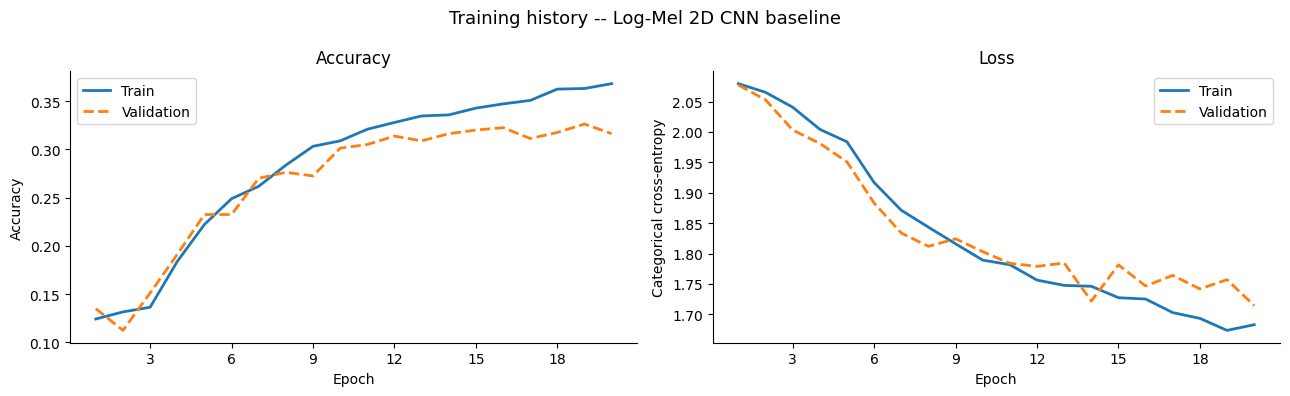

Final train accuracy : 0.3680  (36.80%)
Final val   accuracy : 0.3162  (31.62%)

Training history plot : 0.62s


In [12]:
_t0 = _time_module.perf_counter()

hist = history.history
epochs_range = range(1, len(hist["accuracy"]) + 1)

fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(13, 4))

ax_acc.plot(epochs_range, hist["accuracy"],     label="Train",      linewidth=2)
ax_acc.plot(epochs_range, hist["val_accuracy"], label="Validation", linewidth=2, linestyle="--")
ax_acc.set_title("Accuracy")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend()
ax_acc.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for spine in ["top", "right"]:
    ax_acc.spines[spine].set_visible(False)

ax_loss.plot(epochs_range, hist["loss"],     label="Train",      linewidth=2)
ax_loss.plot(epochs_range, hist["val_loss"], label="Validation", linewidth=2, linestyle="--")
ax_loss.set_title("Loss")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Categorical cross-entropy")
ax_loss.legend()
ax_loss.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for spine in ["top", "right"]:
    ax_loss.spines[spine].set_visible(False)

fig.suptitle("Training history -- Log-Mel 2D CNN baseline", fontsize=13)
plt.tight_layout()
plt.show()

final_train_acc = hist["accuracy"][-1]
final_val_acc   = hist["val_accuracy"][-1]
print(f"Final train accuracy : {final_train_acc:.4f}  ({final_train_acc:.2%})")
print(f"Final val   accuracy : {final_val_acc:.4f}  ({final_val_acc:.2%})")

_section_times["8. Training history plot"] = _time_module.perf_counter() - _t0
print(f"\nTraining history plot : {_section_times['8. Training history plot']:.2f}s")


## 9. Evaluate the Model


In [13]:
import json as _json

_t0 = _time_module.perf_counter()


def eval_dataset(model, ds: tf.data.Dataset, genre_classes, split_label: str):
    y_true, y_pred = [], []
    for xb, yb in ds:
        pred = model(xb, training=False).numpy()
        y_pred.append(np.argmax(pred, axis=1))
        y_true.append(np.argmax(yb.numpy(), axis=1))
    y_true = np.concatenate(y_true) if y_true else np.array([], dtype=np.int64)
    y_pred = np.concatenate(y_pred) if y_pred else np.array([], dtype=np.int64)

    acc      = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    cr_text  = classification_report(y_true, y_pred, target_names=genre_classes, zero_division=0)
    cr_dict  = classification_report(y_true, y_pred, target_names=genre_classes, zero_division=0, output_dict=True)
    block = (
        f"\n{'='*60}\n {split_label}\n{'='*60}\n"
        f"  Accuracy : {acc:.4f}  ({acc:.2%})\n"
        f"  Macro-F1 : {macro_f1:.4f}\n\n"
        f"Per-genre classification report:\n{cr_text}"
    )
    print(block)

    per_genre = {
        g: {k: round(float(v), 4) for k, v in cr_dict[g].items()}
        for g in genre_classes
        if g in cr_dict
    }
    metrics = {
        "accuracy":  round(float(acc), 4),
        "macro_f1":  round(float(macro_f1), 4),
        "per_genre": per_genre,
    }
    return block, y_true, y_pred, metrics


with tf.device(RUNTIME_DEVICE):
    train_block, y_train_true, y_train_pred, train_metrics = eval_dataset(model, train_ds, GENRE_CLASSES, "TRAIN SET")
    val_block,   y_val_true,   y_val_pred,   val_metrics   = eval_dataset(model, val_ds,   GENRE_CLASSES, "VALIDATION SET")
    test_block,  y_test_true,  y_test_pred,  test_metrics  = eval_dataset(model, test_ds,  GENRE_CLASSES, "TEST SET")

_section_times["9. Evaluation"] = _time_module.perf_counter() - _t0
print(f"\nEvaluation : {_section_times['9. Evaluation']:.2f}s")

_report = _json.loads(REPORT_PATH.read_text())
_report["evaluation"] = {
    "timing_seconds": round(_section_times["9. Evaluation"], 2),
    "splits": {
        "train":      train_metrics,
        "validation": val_metrics,
        "test":       test_metrics,
    },
}
REPORT_PATH.write_text(_json.dumps(_report, indent=2))
print(f"Report updated -> {REPORT_PATH}")


2026-03-06 11:54:10.969856: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:422] ShuffleDatasetV3:8: Filling up shuffle buffer (this may take a while): 2061 of 4096
2026-03-06 11:54:23.947749: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:452] Shuffle buffer filled.



 TRAIN SET
  Accuracy : 0.3704  (37.04%)
  Macro-F1 : 0.3330

Per-genre classification report:
               precision    recall  f1-score   support

   Electronic       0.43      0.17      0.24       799
 Experimental       0.34      0.07      0.11       799
         Folk       0.36      0.58      0.44       800
      Hip-Hop       0.38      0.78      0.51       799
 Instrumental       0.31      0.52      0.39       800
International       0.27      0.15      0.19       800
          Pop       0.28      0.20      0.24       800
         Rock       0.57      0.51      0.54       799

     accuracy                           0.37      6396
    macro avg       0.37      0.37      0.33      6396
 weighted avg       0.37      0.37      0.33      6396


 VALIDATION SET
  Accuracy : 0.3162  (31.62%)
  Macro-F1 : 0.2711

Per-genre classification report:
               precision    recall  f1-score   support

   Electronic       0.26      0.10      0.14       100
 Experimental       0.24     

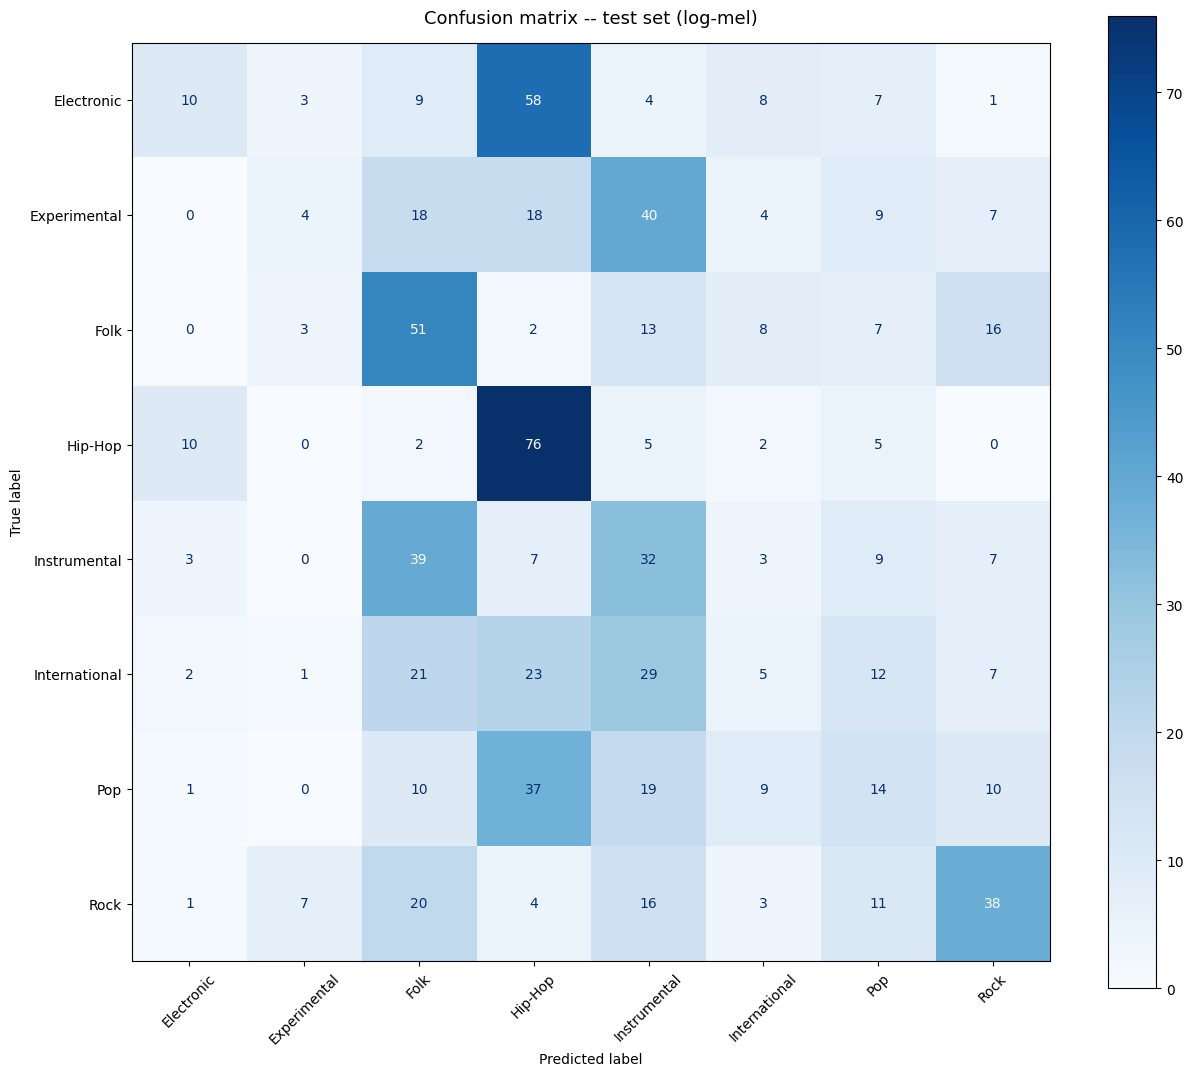

Confusion matrix : 0.82s


In [14]:
_t0 = _time_module.perf_counter()

cm = confusion_matrix(y_test_true, y_test_pred)

fig, ax = plt.subplots(figsize=(13, 11))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GENRE_CLASSES)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues", values_format="d")
ax.set_title("Confusion matrix -- test set (log-mel)", fontsize=13, pad=14)
plt.tight_layout()
plt.show()

_section_times["9b. Confusion matrix"] = _time_module.perf_counter() - _t0
print(f"Confusion matrix : {_section_times['9b. Confusion matrix']:.2f}s")


## 10. Predict on a New Audio Sample



Predicted genre : Hip-Hop  (confidence: 41.66%)
True genre      : ?


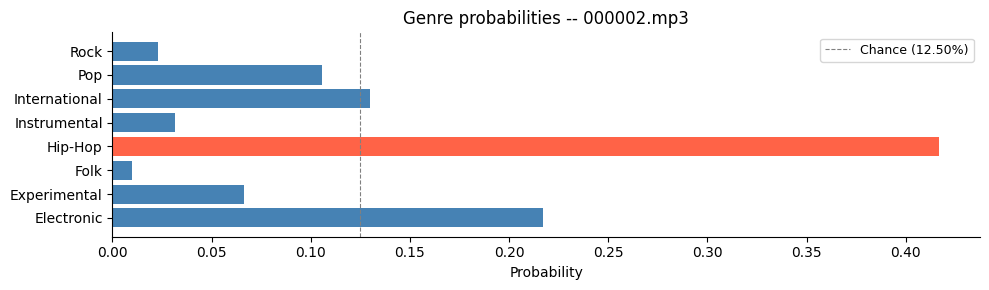


Inference : 25.08s


In [15]:
_t0 = _time_module.perf_counter()

INFER_PATH = "../../FMA/fma_medium/000/000002.mp3"

if INFER_PATH is None:
    rng_idx    = np.random.randint(len(test_df))
    INFER_PATH = Path(test_df.iloc[rng_idx]["filepath"])
    true_genre = test_df.iloc[rng_idx]["genre_top"]
    print(f"Using test sample: {INFER_PATH.name}  (true genre: {true_genre})")
else:
    INFER_PATH = Path(INFER_PATH)
    true_genre = "?"

try:
    y = _load_audio_simple(INFER_PATH, sr=SAMPLE_RATE, mono=True, duration=30.0)
    ok, reason = _sanity_check_audio(y, SAMPLE_RATE)
    if not ok:
        raise ValueError(f"sanity_check_failed:{reason}")
    logmel = _logmel_fixed_shape(y)
except Exception as exc:
    print(f"Could not load/extract log-mel: {exc}")
    logmel = None

if logmel is not None:
    x_infer = ((logmel[np.newaxis, ..., np.newaxis] - mu) / std).astype(np.float32)

    probs      = model.predict(x_infer, verbose=0)[0]
    pred_idx   = int(np.argmax(probs))
    pred_genre = GENRE_CLASSES[pred_idx]
    confidence = float(probs[pred_idx])

    print(f"\nPredicted genre : {pred_genre}  (confidence: {confidence:.2%})")
    print(f"True genre      : {true_genre}")

    fig, ax = plt.subplots(figsize=(10, 3))
    colors = ["steelblue" if g != pred_genre else "tomato" for g in GENRE_CLASSES]
    ax.barh(GENRE_CLASSES, probs, color=colors)
    ax.set_xlabel("Probability")
    ax.set_title(f"Genre probabilities -- {INFER_PATH.name}")
    ax.axvline(1 / N_CLASSES, color="grey", linestyle="--", linewidth=0.8, label=f"Chance ({1/N_CLASSES:.2%})")
    ax.legend(fontsize=9)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()

_section_times["10. Inference"] = _time_module.perf_counter() - _t0
print(f"\nInference : {_section_times['10. Inference']:.2f}s")


---

## Runtime Summary


In [16]:
_total = _time_module.perf_counter() - _T0

SEP = "=" * 52
print(SEP)
print("  Runtime summary")
print(SEP)
for section, elapsed in _section_times.items():
    bar_len  = max(1, int(elapsed / _total * 30))
    bar      = "█" * bar_len
    pct      = elapsed / _total * 100
    mins, secs = divmod(elapsed, 60)
    time_str = f"{int(mins)}m {secs:04.1f}s" if mins else f"{elapsed:6.1f}s"
    print(f"  {section:<28}  {time_str:>9}  {pct:5.1f}%  {bar}")

print(SEP)
mins_total, secs_total = divmod(_total, 60)
total_str = f"{int(mins_total)}m {secs_total:04.1f}s" if mins_total else f"{_total:.1f}s"
print(f"  {'TOTAL':<28}  {total_str:>9}")
print(SEP)


  Runtime summary
  2. Device setup                    4.0s    0.4%  █
  3. Load manifest                   0.2s    0.0%  █
  3b. Genre plot                     1.1s    0.1%  █
  4. Log-mel TFRecord build          0.2s    0.0%  █
  4b. Log-mel plot                   0.7s    0.1%  █
  5. Preprocessing                   0.5s    0.1%  █
  6. Build model                     0.1s    0.0%  █
  7. Compile & train            14m 22.3s   90.0%  ██████████████████████████
  8. Training history plot           0.6s    0.1%  █
  9. Evaluation                     57.7s    6.0%  █
  9b. Confusion matrix               0.8s    0.1%  █
  10. Inference                     25.1s    2.6%  █
  TOTAL                         15m 58.6s
